<h1 style="color:#56B4E9;">Week 7 — Day 2</h1>

<h2 style="color:#0072B2;">Building CNNs & Transfer Learning</h2>

### Melanoma Skin Cancer Classification

Day 1 established the motivation for using a two-dimensional Convolutional Neural Network for dermoscopic skin-lesion images. We examined convolution, feature maps, stride, padding, and parameter sharing, and confirmed that CNNs are more suitable than dense-only networks for preserving spatial image information.

Day 2 moves from individual convolution operations to complete image-classification models. We will first study pooling and build a CNN from scratch. We will then introduce data augmentation to reduce overfitting and finally apply transfer learning using a pre-trained image model.

The experiments will be evaluated using the validation set while keeping the test set untouched until the final evaluation.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Explain how pooling reduces the spatial size of feature maps.
- Build a complete CNN using convolution, pooling, flattening, and dense layers.
- Train a CNN from scratch on the melanoma image dataset.
- Apply data augmentation to improve generalization and reduce overfitting.
- Use transfer learning with a pre-trained image-classification model.
- Compare validation performance and training time across different approaches.
- Identify which approach provides the strongest practical result for the image-classification project.

<h2 style="color:#0072B2;">Day 2 Experimental Plan</h2>

<span style="color:#D55E00;"><b>Problem:</b></span>  
A CNN built from scratch can learn useful image features, but a limited dataset may cause overfitting. The model may also require considerable training time before learning strong visual representations.

<span style="color:#009E73;"><b>Today's Goal:</b></span>  
Build a complete CNN, improve its generalization using data augmentation, and compare it with a pre-trained transfer-learning model.

### Experimental Sequence

1. Create a stratified validation split from the training data.
2. Examine how pooling changes feature-map dimensions.
3. Build and train a CNN from scratch.
4. Add data augmentation and compare validation behavior.
5. Apply transfer learning using a pre-trained MobileNetV2 model.
6. Compare accuracy, validation performance, and training time.
7. Determine which approach should be carried forward to the next stage.

<span style="color:#D55E00;"><b>Evaluation Rule:</b></span>  
The test set will remain untouched during all experiments. It will only be used after selecting the final model.

In [3]:
from pathlib import Path
import random
import time

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    RandomFlip,
    RandomRotation,
    RandomZoom
)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Environment prepared successfully.")
print("TensorFlow version:", tf.__version__)

Environment prepared successfully.
TensorFlow version: 2.21.0


In [4]:
dataset_path = Path(
    kagglehub.dataset_download(
        "ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant"
    )
)

print("Dataset path:")
print(dataset_path)

Dataset path:
/home/haitham/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1


In [5]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for image_path in dataset_path.rglob("*"):
    if not image_path.is_file():
        continue

    if image_path.suffix.lower() not in image_extensions:
        continue

    path_parts = [part.lower() for part in image_path.parts]

    label = next(
        (
            class_name
            for class_name in ["benign", "malignant"]
            if class_name in path_parts
        ),
        None
    )

    split = next(
        (
            split_name
            for split_name in ["train", "validation", "valid", "val", "test"]
            if split_name in path_parts
        ),
        "unspecified"
    )

    if label is not None:
        records.append({
            "path": image_path,
            "split": split,
            "label": label
        })

image_data = pd.DataFrame(records)

print("Detected images:", len(image_data))
display(image_data.head())

Detected images: 13879


,path,split,label
0,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
1,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
2,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
3,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
4,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign


<h2 style="color:#0072B2;">Validation Split Preparation</h2>

The dataset inspected on Day 1 contains separate training and test sets but no dedicated validation set.

A validation subset will therefore be created from the training images. Stratification will preserve approximately the same benign-to-malignant class ratio in both subsets.

The test set remains completely untouched.

We will use `20%` of the original training data for validation.

In [6]:
train_data = image_data[
    image_data["split"] == "train"
].copy()

test_data = image_data[
    image_data["split"] == "test"
].copy()

train_data, validation_data = train_test_split(
    train_data,
    test_size=0.20,
    random_state=SEED,
    stratify=train_data["label"]
)

train_data = train_data.reset_index(drop=True)
validation_data = validation_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

validation_distribution = pd.crosstab(
    validation_data["label"],
    columns="Count"
)

split_summary = pd.DataFrame([
    {
        "Split": "Training",
        "Images": len(train_data),
        "Benign": (train_data["label"] == "benign").sum(),
        "Malignant": (train_data["label"] == "malignant").sum()
    },
    {
        "Split": "Validation",
        "Images": len(validation_data),
        "Benign": (validation_data["label"] == "benign").sum(),
        "Malignant": (validation_data["label"] == "malignant").sum()
    },
    {
        "Split": "Test",
        "Images": len(test_data),
        "Benign": (test_data["label"] == "benign").sum(),
        "Malignant": (test_data["label"] == "malignant").sum()
    }
])

display(split_summary)

,Split,Images,Benign,Malignant
0,Training,9503,5031,4472
1,Validation,2376,1258,1118
2,Test,2000,1000,1000


<h2 style="color:#0072B2;">2.1 Pooling</h2>

Pooling is used in CNNs to reduce the spatial dimensions of feature maps while preserving the most important information.

One of the most common pooling operations is <b>Max Pooling</b>. It divides a feature map into small regions and keeps only the maximum value from each region.

This reduces the number of spatial values that subsequent layers need to process and makes the network less sensitive to small changes in the exact location of detected features.

In this experiment, we will visualize the effect of Max Pooling on a feature map.

In [7]:
feature_map = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
], dtype=np.float32)

pooling_layer = MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)

input_map = tf.constant(
    feature_map.reshape(1, 4, 4, 1)
)

pooled_map = pooling_layer(input_map)

print("Original feature map:")
print(feature_map)

print("\nPooled feature map:")
print(pooled_map.numpy().squeeze())

Original feature map:
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]

Pooled feature map:
[[ 6.  8.]
 [14. 16.]]


E0000 00:00:1788196777.897408   28267 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<h3 style="color:#009E73;">Pooling Result</h3>

The original feature map has a spatial size of <b>4 × 4</b>. After applying a `2 × 2` Max Pooling operation with a stride of `2`, the spatial dimensions are reduced to <b>2 × 2</b>.

For each `2 × 2` region, only the largest value is retained:

- Top-left region → `6`
- Top-right region → `8`
- Bottom-left region → `14`
- Bottom-right region → `16`

This demonstrates how pooling reduces the spatial size of feature maps while keeping the strongest detected responses.

<h2 style="color:#0072B2;">Pooling on a Real Melanoma Image</h2>

After observing Max Pooling on a simple numerical feature map, we will now apply the same operation to an actual melanoma image from the dataset.

The image will first be resized to a fixed resolution and normalized. A `2 × 2` Max Pooling layer with a stride of `2` will then be applied independently to the spatial dimensions.

The purpose of this experiment is to visualize how pooling reduces the spatial resolution of a real image while retaining the strongest local responses.

In [8]:
sample_path = train_data.iloc[0]["path"]
sample_label = train_data.iloc[0]["label"]

image = Image.open(sample_path).convert("RGB")
image = image.resize((128, 128))

image_array = np.array(image).astype("float32") / 255.0

pooling_layer = MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2),
    padding="valid"
)

image_tensor = tf.expand_dims(image_array, axis=0)

pooled_image = pooling_layer(image_tensor)

pooled_image = pooled_image.numpy().squeeze()

print("Label:", sample_label)
print("Original image shape:", image_array.shape)
print("Pooled image shape:", pooled_image.shape)

Label: benign
Original image shape: (128, 128, 3)
Pooled image shape: (64, 64, 3)


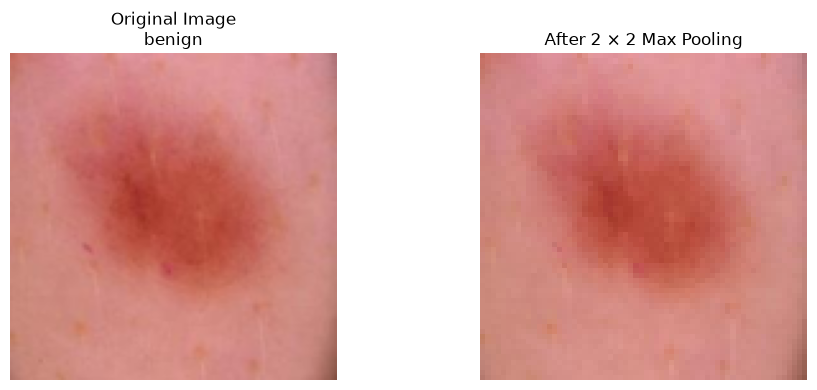

In [9]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title(f"Original Image\n{sample_label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.clip(pooled_image, 0, 1))
plt.title("After 2 × 2 Max Pooling")
plt.axis("off")

plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Real Image Pooling Result</h3>

The original image has a spatial resolution of `128 × 128` pixels. After applying `2 × 2` Max Pooling with a stride of `2`, the spatial resolution becomes `64 × 64`.

The number of channels remains unchanged because the pooling operation is performed independently across the spatial dimensions for each channel.

<span style="color:#D55E00;"><b>Observation:</b></span>

Pooling significantly reduces the spatial size of the image representation. This reduces the amount of information that subsequent CNN layers need to process while retaining strong local responses.

In a complete CNN, pooling is normally applied to learned feature maps produced by convolutional layers rather than directly to the original image. This experiment is mainly a visual demonstration of the spatial downsampling effect.

<h2 style="color:#0072B2;">2.2 Building a Full CNN</h2>

Now that the effect of pooling is clear, we can combine convolution and pooling layers into a complete CNN architecture.

The model will progressively learn visual features from the melanoma images:

- Early convolutional layers will learn simple patterns such as edges and textures.
- Deeper convolutional layers will learn more complex visual patterns.
- Max Pooling will reduce the spatial dimensions of the feature maps.
- Flattening will convert the learned feature maps into a one-dimensional representation.
- Dense layers will use these learned features to perform the final binary classification.

This model will be trained from scratch without using any pre-trained weights.

In [10]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    
    label = tf.cast(label, tf.float32)
    
    return image, label

In [11]:
label_map = {
    "benign": 0,
    "malignant": 1
}

train_paths = train_data["path"].astype(str).values
train_labels = train_data["label"].map(label_map).values

validation_paths = validation_data["path"].astype(str).values
validation_labels = validation_data["label"].map(label_map).values

test_paths = test_data["path"].astype(str).values
test_labels = test_data["label"].map(label_map).values

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

validation_dataset = tf.data.Dataset.from_tensor_slices(
    (validation_paths, validation_labels)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

train_dataset = (
    train_dataset
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(len(train_data), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Training batches: 297
Validation batches: 75
Test batches: 63


<h3 style="color:#009E73;">Input Pipeline</h3>

The images are resized to `128 × 128` pixels and normalized to the range `[0, 1]`.

The datasets are then batched and prefetched to make the training process more efficient.

The labels are encoded as:

- `0` → Benign
- `1` → Malignant

The same preprocessing is applied to the training, validation, and test sets.

<h3 style="color:#0072B2;">CNN Architecture</h3>

The first CNN will contain three convolutional blocks.

Each block consists of:

1. A convolutional layer to extract visual features.
2. A Max Pooling layer to reduce the spatial dimensions.

After the convolutional blocks, the feature maps will be flattened and passed through dense layers for binary classification.

The model will use a sigmoid output because this is a two-class classification problem.

In [12]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

/home/haitham/binx-ai-ml-internship/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

<h3 style="color:#009E73;">Model Design</h3>

The CNN progressively increases the number of filters from `32` to `64` and then `128`.

At the same time, Max Pooling reduces the spatial dimensions of the feature maps after each convolutional block.

This creates a common CNN pattern:

<b>Convolution → Pooling → Convolution → Pooling → Convolution → Pooling → Classification</b>

The final sigmoid neuron produces a value between `0` and `1`, representing the predicted probability of the malignant class.

<h2 style="color:#0072B2;">2.3 Training the CNN from Scratch</h2>

The CNN architecture is now ready for training.

The model will be trained on the training dataset and evaluated after each epoch using the validation dataset.

The test dataset will remain untouched during this experiment.

In [13]:
EPOCHS = 10

start_time = time.time()

cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

cnn_training_time = time.time() - start_time

print(
    f"\nCNN training time: "
    f"{cnn_training_time / 60:.2f} minutes"
)

Epoch 1/10


/home/haitham/binx-ai-ml-internship/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


297/297 ━━━━━━━━━━━━━━━━━━━━ 73s 228ms/step - accuracy: 0.7556 - loss: 0.4925 - val_accuracy: 0.7778 - val_loss: 0.4500
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - accuracy: 0.8283 - loss: 0.3895 - val_accuracy: 0.8565 - val_loss: 0.3507
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 64s 207ms/step - accuracy: 0.8420 - loss: 0.3558 - val_accuracy: 0.8468 - val_loss: 0.3521
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 65s 211ms/step - accuracy: 0.8550 - loss: 0.3340 - val_accuracy: 0.8540 - val_loss: 0.3416
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 66s 216ms/step - accuracy: 0.8555 - loss: 0.3264 - val_accuracy: 0.8152 - val_loss: 0.4059
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 61s 200ms/step - accuracy: 0.8633 - loss: 0.3140 - val_accuracy: 0.8607 - val_loss: 0.3318
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 64s 210ms/step - accuracy: 0.8690 - loss: 0.3000 - val_accuracy: 0.8645 - val_loss: 0.3208
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 70s 230ms/step - accuracy: 0.8773 - loss: 0.2902 - val

<h3 style="color:#009E73;">CNN Training Result</h3>

The CNN trained from scratch reached its strongest validation accuracy of approximately `87.37%`.

The best validation loss was approximately `0.3067`.

The model required approximately `11.19 minutes` to complete ten training epochs.

The training and validation results will now be visualized to examine the learning behavior.

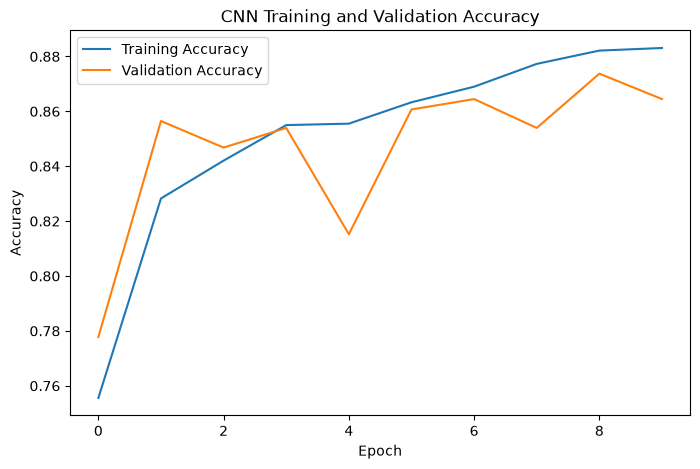

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")

plt.legend()
plt.show()

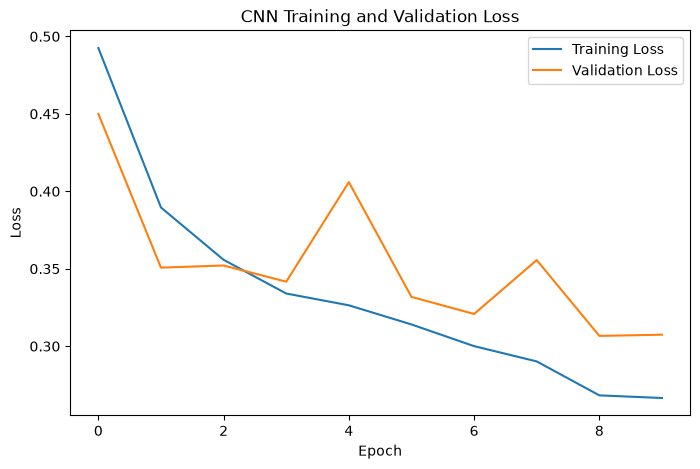

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")

plt.legend()
plt.show()

In [17]:
cnn_best_val_accuracy = max(
    cnn_history.history["val_accuracy"]
)

cnn_best_val_loss = min(
    cnn_history.history["val_loss"]
)

print("CNN from Scratch Results")
print(
    f"Best Validation Accuracy: "
    f"{cnn_best_val_accuracy:.4f}"
)

print(
    f"Best Validation Loss: "
    f"{cnn_best_val_loss:.4f}"
)

print(
    f"Training Time: "
    f"{cnn_training_time / 60:.2f} minutes"
)

CNN from Scratch Results
Best Validation Accuracy: 0.8737
Best Validation Loss: 0.3067
Training Time: 11.19 minutes


<h2 style="color:#0072B2;">2.4 Data Augmentation</h2>

The CNN trained from scratch achieved good validation performance, but the training data can still be expanded artificially during training.

Data augmentation creates modified versions of training images.

In this experiment, the following transformations will be applied:

- Horizontal flipping.
- Small rotations.
- Small zoom operations.

The purpose is to increase training-image diversity and improve model generalization.

The validation and test datasets remain unchanged.

In [18]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

data_augmentation

<Sequential name=sequential_1, built=False>

<h3 style="color:#009E73;">CNN with Data Augmentation</h3>

A new CNN will be trained using the same architecture as the original CNN.

The difference is that data augmentation is applied to the training images before they pass through the convolutional layers.

This allows a fair comparison between the original CNN and the augmented CNN.

In [19]:
augmented_cnn_model = Sequential([
    data_augmentation,

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 3)
    ),
    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    MaxPooling2D((2, 2)),

    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

augmented_cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

augmented_cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

<h3 style="color:#009E73;">Training CNN with Data Augmentation</h3>

The CNN architecture remains the same.

The difference is that augmented versions of the training images will be generated during training.

The validation dataset remains unchanged so that the results can be compared fairly with the original CNN.

In [20]:
start_time = time.time()

augmented_cnn_history = augmented_cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

augmented_cnn_training_time = time.time() - start_time

print(
    f"\nAugmented CNN training time: "
    f"{augmented_cnn_training_time / 60:.2f} minutes"
)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - accuracy: 0.7647 - loss: 0.4834 - val_accuracy: 0.8253 - val_loss: 0.3975
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 68s 223ms/step - accuracy: 0.8213 - loss: 0.4037 - val_accuracy: 0.8443 - val_loss: 0.3579
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 65s 209ms/step - accuracy: 0.8350 - loss: 0.3709 - val_accuracy: 0.8485 - val_loss: 0.3606
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 62s 203ms/step - accuracy: 0.8404 - loss: 0.3590 - val_accuracy: 0.8497 - val_loss: 0.3611
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 68s 223ms/step - accuracy: 0.8413 - loss: 0.3602 - val_accuracy: 0.8531 - val_loss: 0.3623
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 66s 216ms/step - accuracy: 0.8459 - loss: 0.3478 - val_accuracy: 0.8510 - val_loss: 0.3478
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 67s 214ms/step - accuracy: 0.8527 - loss: 0.3356 - val_accuracy: 0.8506 - val_loss: 0.3426
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 65s 214ms/step - accuracy: 0.8520 - loss: 0

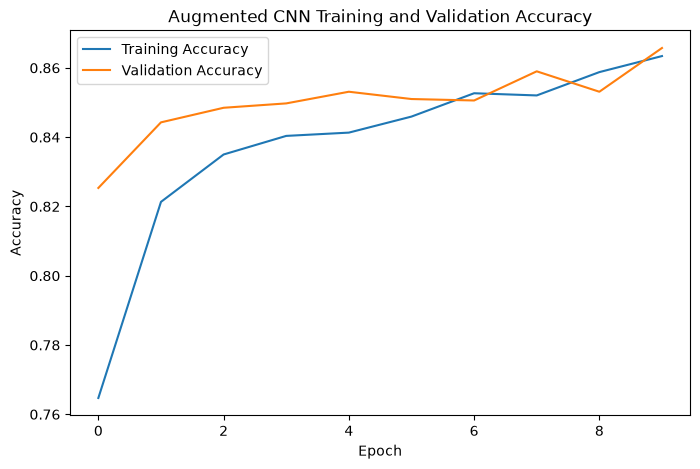

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    augmented_cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    augmented_cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Augmented CNN Training and Validation Accuracy"
)

plt.legend()
plt.show()

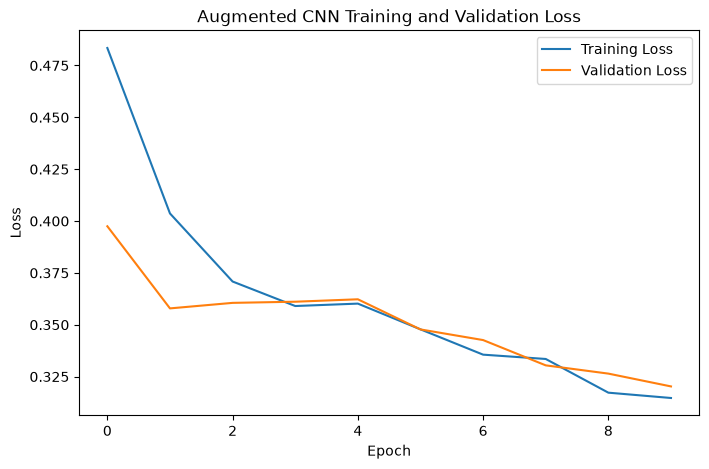

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    augmented_cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    augmented_cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Augmented CNN Training and Validation Loss"
)

plt.legend()
plt.show()

In [22]:
augmented_cnn_best_val_accuracy = max(
    augmented_cnn_history.history["val_accuracy"]
)

augmented_cnn_best_val_loss = min(
    augmented_cnn_history.history["val_loss"]
)

print("CNN with Data Augmentation Results")
print(
    f"Best Validation Accuracy: "
    f"{augmented_cnn_best_val_accuracy:.4f}"
)
print(
    f"Best Validation Loss: "
    f"{augmented_cnn_best_val_loss:.4f}"
)
print(
    f"Training Time: "
    f"{augmented_cnn_training_time / 60:.2f} minutes"
)

CNN with Data Augmentation Results
Best Validation Accuracy: 0.8657
Best Validation Loss: 0.3203
Training Time: 11.95 minutes


<h3 style="color:#009E73;">Data Augmentation Result</h3>

The CNN with data augmentation reached a best validation accuracy of approximately `86.57%`.

The best validation loss was approximately `0.3203`.

Training required approximately `11.95 minutes`.

Compared with the original CNN, data augmentation produced a slightly lower validation accuracy in this experiment. However, augmentation can still be useful because it introduces additional variation during training and can improve robustness in other training configurations.

<h2 style="color:#0072B2;">2.5 Transfer Learning with MobileNetV2</h2>

The previous models learned their visual features directly from the available melanoma dataset.

Transfer learning takes a different approach.

A pre-trained image model already contains learned visual representations from a large image dataset. These learned features can be reused for a new classification problem.

In this experiment, MobileNetV2 will be used as a frozen feature extractor.

In [25]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print(
    "Number of layers in MobileNetV2:",
    len(base_model.layers)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Number of layers in MobileNetV2: 154


<h3 style="color:#009E73;">Frozen Feature Extractor</h3>

The MobileNetV2 model contains `154` layers.

Its pre-trained parameters are frozen, meaning that they will not be updated during training.

A new classification layer will be trained on top of the pre-trained feature extractor.

The input images are also rescaled to the range expected by MobileNetV2.

In [26]:
transfer_model = Sequential([
    tf.keras.layers.Rescaling(
        2.0,
        offset=-1.0,
        input_shape=(128, 128, 3)
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    Dense(
        1,
        activation="sigmoid"
    )
])

transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
start_time = time.time()

transfer_history = transfer_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

transfer_training_time = time.time() - start_time

print(
    f"\nTransfer Learning training time: "
    f"{transfer_training_time / 60:.2f} minutes"
)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 88s 259ms/step - accuracy: 0.8255 - loss: 0.3866 - val_accuracy: 0.8514 - val_loss: 0.3395
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 84s 276ms/step - accuracy: 0.8620 - loss: 0.3104 - val_accuracy: 0.8641 - val_loss: 0.3088
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 85s 281ms/step - accuracy: 0.8743 - loss: 0.2901 - val_accuracy: 0.8729 - val_loss: 0.2965
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 85s 279ms/step - accuracy: 0.8807 - loss: 0.2757 - val_accuracy: 0.8712 - val_loss: 0.3012
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 81s 268ms/step - accuracy: 0.8850 - loss: 0.2664 - val_accuracy: 0.8758 - val_loss: 0.2904
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 82s 271ms/step - accuracy: 0.8920 - loss: 0.2595 - val_accuracy: 0.8763 - val_loss: 0.2917
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 81s 261ms/step - accuracy: 0.8911 - loss: 0.2562 - val_accuracy: 0.8708 - val_loss: 0.3023
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 78s 256ms/step - accuracy: 0.8932 - loss: 0

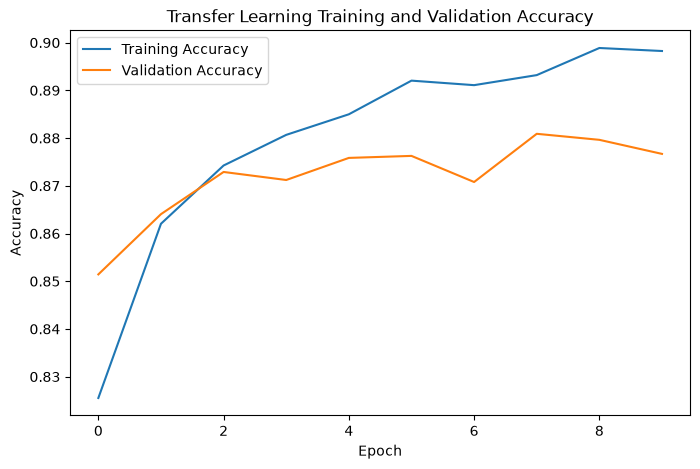

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    transfer_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    transfer_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Transfer Learning Training and Validation Accuracy"
)

plt.legend()
plt.show()

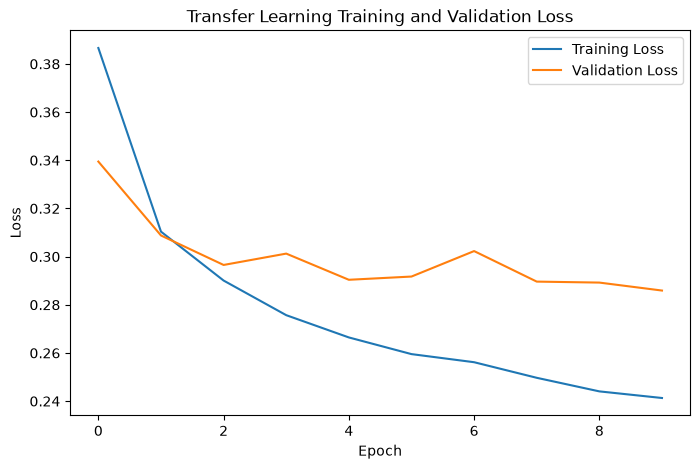

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    transfer_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    transfer_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Transfer Learning Training and Validation Loss"
)

plt.legend()
plt.show()

In [28]:
transfer_best_val_accuracy = max(
    transfer_history.history["val_accuracy"]
)

transfer_best_val_loss = min(
    transfer_history.history["val_loss"]
)

print("Transfer Learning Results")
print(
    f"Best Validation Accuracy: "
    f"{transfer_best_val_accuracy:.4f}"
)
print(
    f"Best Validation Loss: "
    f"{transfer_best_val_loss:.4f}"
)
print(
    f"Training Time: "
    f"{transfer_training_time / 60:.2f} minutes"
)

Transfer Learning Results
Best Validation Accuracy: 0.8809
Best Validation Loss: 0.2859
Training Time: 13.75 minutes


<h3 style="color:#009E73;">Transfer Learning Result</h3>

Transfer learning using MobileNetV2 achieved the strongest validation performance among the three approaches.

The best validation accuracy was approximately `88.09%`.

The best validation loss was approximately `0.2859`.

The model required approximately `13.75 minutes` to complete training.

Although transfer learning required slightly more training time in this experiment, it achieved the strongest validation accuracy and the lowest validation loss.

<h2 style="color:#0072B2;">2.6 Model Comparison</h2>

The three approaches can now be compared using their validation performance and training time.

The compared approaches are:

1. CNN trained from scratch.
2. CNN with data augmentation.
3. Transfer learning using MobileNetV2.

The test dataset remains untouched while selecting the strongest model.

In [33]:
comparison_results = pd.DataFrame([
    {
        "Model": "CNN from Scratch",
        "Best Validation Accuracy":
            cnn_best_val_accuracy,
        "Best Validation Loss":
            cnn_best_val_loss,
        "Training Time (minutes)":
            cnn_training_time / 60
    },

    {
        "Model": "CNN + Data Augmentation",
        "Best Validation Accuracy":
            augmented_cnn_best_val_accuracy,
        "Best Validation Loss":
            augmented_cnn_best_val_loss,
        "Training Time (minutes)":
            augmented_cnn_training_time / 60
    },

    {
        "Model": "MobileNetV2 Transfer Learning",
        "Best Validation Accuracy":
            transfer_best_val_accuracy,
        "Best Validation Loss":
            transfer_best_val_loss,
        "Training Time (minutes)":
            transfer_training_time / 60
    }
])

comparison_results = (
    comparison_results
    .sort_values(
        "Best Validation Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(comparison_results)

,Model,Best Validation Accuracy,Best Validation Loss,Training Time (minutes)
0,MobileNetV2 Transfer Learning,0.880892,0.285913,13.750539
1,CNN from Scratch,0.873737,0.306659,11.194589
2,CNN + Data Augmentation,0.865741,0.320274,11.947882


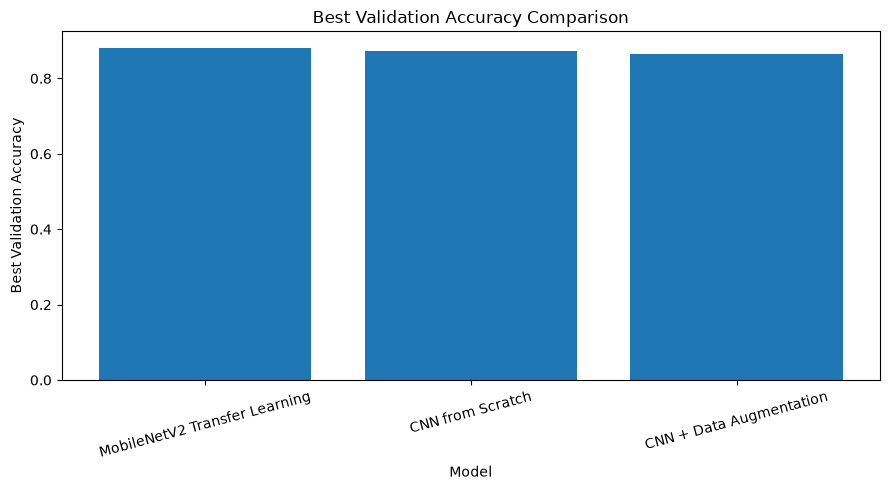

In [34]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_results["Model"],
    comparison_results["Best Validation Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Best Validation Accuracy")

plt.title(
    "Best Validation Accuracy Comparison"
)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

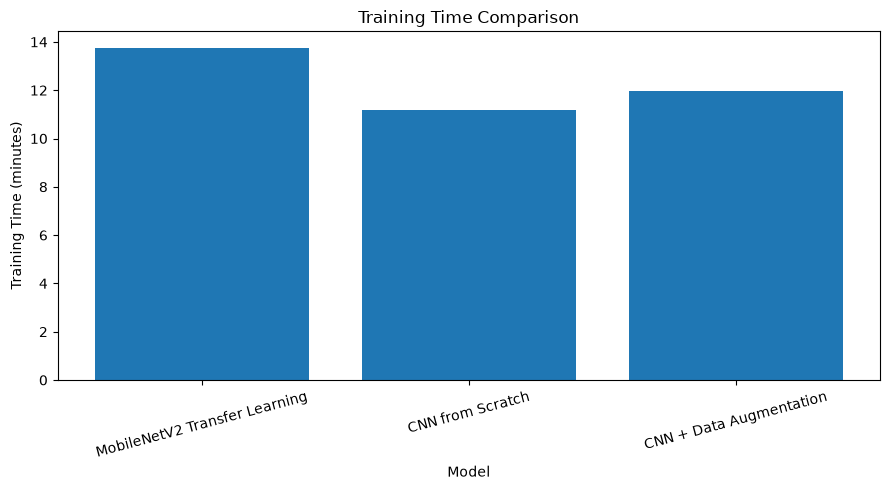

In [35]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_results["Model"],
    comparison_results["Training Time (minutes)"]
)

plt.xlabel("Model")
plt.ylabel("Training Time (minutes)")

plt.title(
    "Training Time Comparison"
)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Comparison Summary</h3>

The results show the following best validation accuracies:

- CNN from Scratch → approximately `87.37%`
- CNN with Data Augmentation → approximately `86.57%`
- MobileNetV2 Transfer Learning → approximately `88.09%`

The MobileNetV2 transfer-learning approach achieved the strongest validation accuracy.

It also achieved the lowest validation loss among the three approaches.

The validation results therefore support selecting the MobileNetV2 transfer-learning model for final evaluation.

In [36]:
model_objects = {
    "CNN from Scratch": cnn_model,

    "CNN + Data Augmentation":
        augmented_cnn_model,

    "MobileNetV2 Transfer Learning":
        transfer_model
}

best_model_name = (
    comparison_results.iloc[0]["Model"]
)

best_model = model_objects[
    best_model_name
]

print("Selected Final Model:")
print(best_model_name)

Selected Final Model:
MobileNetV2 Transfer Learning


<h2 style="color:#0072B2;">2.7 Final Test Evaluation</h2>

The final model was selected using validation performance.

The test dataset has not been used during model development or model selection.

It will now be used for the first time to evaluate the selected model on unseen melanoma images.

In [37]:
final_test_loss, final_test_accuracy = (
    best_model.evaluate(
        test_dataset,
        verbose=1
    )
)

print("\nFinal Test Results")

print(
    f"Selected Model: "
    f"{best_model_name}"
)

print(
    f"Test Loss: "
    f"{final_test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{final_test_accuracy:.4f}"
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.8845 - loss: 0.2682

Final Test Results
Selected Model: MobileNetV2 Transfer Learning
Test Loss: 0.2682
Test Accuracy: 0.8845


<h2 style="color:#0072B2;">Day 2 Conclusion</h2>

This notebook compared three approaches for melanoma image classification:

1. A CNN trained from scratch.
2. A CNN trained with data augmentation.
3. Transfer learning using a pre-trained MobileNetV2 model.

The CNN trained from scratch achieved strong validation performance and demonstrated that convolutional layers can learn useful visual features directly from the melanoma images.

Data augmentation introduced additional variation during training. In this experiment, it did not improve the best validation accuracy compared with the original CNN.

Transfer learning using MobileNetV2 achieved the strongest validation performance and the lowest validation loss among the evaluated approaches.

The validation results therefore supported selecting MobileNetV2 transfer learning as the final model for evaluation on the untouched test dataset.

This experiment demonstrates the practical value of comparing multiple approaches instead of relying on a single model architecture.